**ЛАБОРАТОРНАЯ РАБОТА №2. Гистограммы, профили и проекции**

Выполнили студенты группы 932302: Лебёдкин Владислав и Травкова Ирина

Вариант 6

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### 0. Чтение исходного изображения

(np.float64(-0.5), np.float64(739.5), np.float64(739.5), np.float64(-0.5))

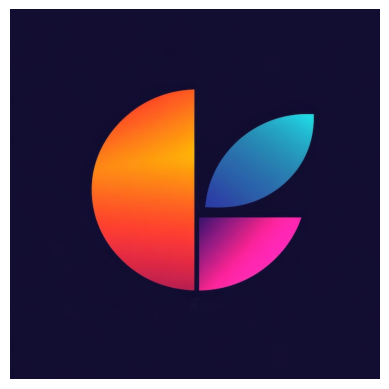

In [12]:
original_image = cv2.imread("abstract.jpg")
changing_image = cv2.cvtColor(original_image,cv2.COLOR_BGR2RGB)
plt.imshow(changing_image)
plt.axis("off")


### 1. Построить гистограмму серого изображения и вычислить дисперсию яркости.

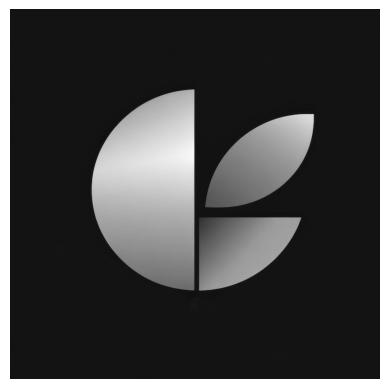

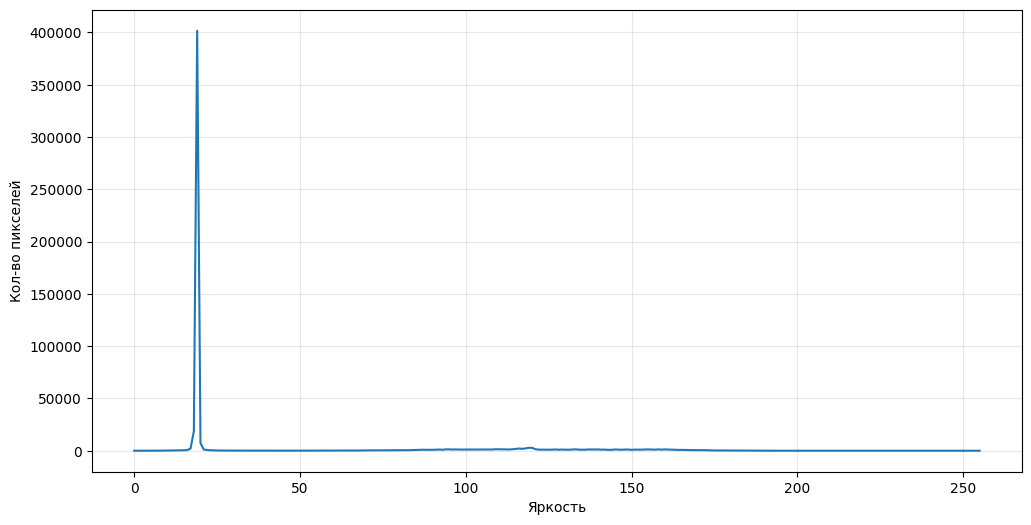

In [13]:
gray_image = cv2.cvtColor(changing_image,cv2.COLOR_RGB2GRAY)
plt.imshow(gray_image, cmap='gray')
plt.axis("off")

gray_hist = cv2.calcHist([gray_image],[0],None,[256],[0,256])
plt.figure(figsize=(12,6))
plt.plot(gray_hist)
plt.xlabel("Яркость")
plt.ylabel("Кол-во пикселей")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
variance = np.var(gray_image)

print(f'Дисперсия яркости: {variance:.2f}')

Дисперсия яркости: 1893.77


### 2. Построить гистограммы R, G, B и определить наиболее насыщенный канал.

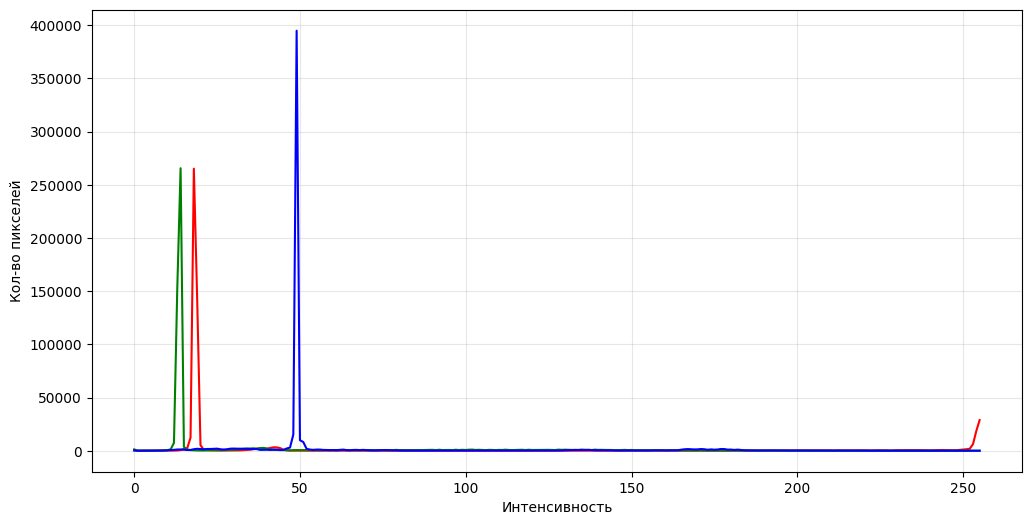

Самый насыщенный канал: 
blue  =  57.616018991964935


In [15]:
channels =["red","green","blue"]
mean_intensity_value = {}

plt.figure(figsize=(12,6))

for channel, color in enumerate(channels):
    rgb_hist = cv2.calcHist([changing_image],[channel],None,[256],[0,256])
    plt.plot(rgb_hist,color = color)

    intensity= np.arange(256)
    mean_intensity = (np.sum(intensity*rgb_hist.flatten())/np.sum(rgb_hist))

    mean_intensity_value[channel]=mean_intensity
    
plt.xlabel("Интенсивность")
plt.ylabel("Кол-во пикселей")
plt.grid(True, alpha=0.3)
plt.show()

max_intensity_channel = max(mean_intensity_value, key=mean_intensity_value.get)
print("Самый насыщенный канал: ")
print(channels[max_intensity_channel], " = ", mean_intensity_value[max_intensity_channel])

### 3. Построить горизонтальный профиль изображения и определить линию с минимальной яркостью.

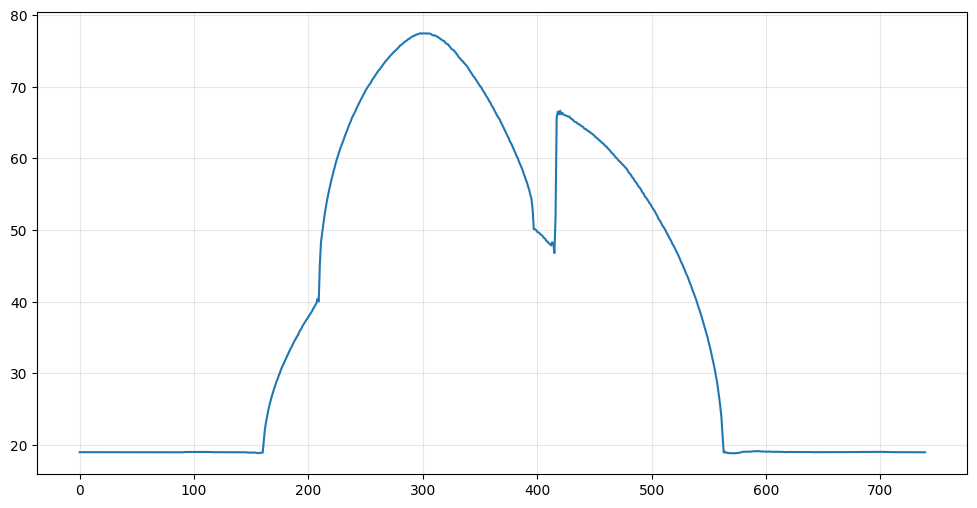

Линия с минимальной яркостью:  571


In [16]:
height, width = gray_image.shape

horizontal_profile = np.mean(gray_image,axis=1)
plt.figure(figsize=(12,6))
plt.plot(horizontal_profile)
plt.grid(True, alpha=0.3)
plt.show()
print("Линия с минимальной яркостью: ", np.argmin(horizontal_profile))

### 4.Построить вертикальную проекцию изображения и определить линию с максимальной яркостью.

**Вертикальная проекция** — это сумма интенсивностей пикселей по каждому столбцу изображения (``axis=0``). 

Для поиска линии с максимальной яркостью находим столбец с максимальным значением проекции:
```python
max_col_idx = np.argmax(vertical_projection)

 Столбец с максимальной проекцией: №367 (сумма = 63425)


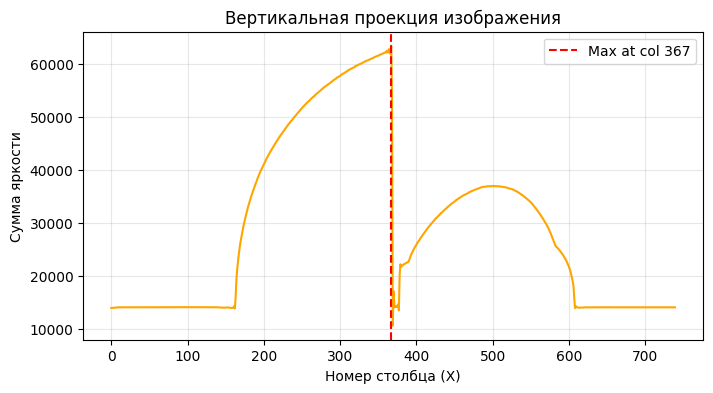

In [17]:
# построение вертикальной проекции
vertical_projection = np.sum(gray_image, axis=0)

# поиск столбца с максимальной проекцией
max_col_idx = np.argmax(vertical_projection)
max_proj_val = vertical_projection[max_col_idx]

print(f' Столбец с максимальной проекцией: №{max_col_idx} (сумма = {max_proj_val:.0f})')

# визуализация
plt.figure(figsize=(8, 4))
plt.plot(vertical_projection, color='orange')
plt.axvline(x=max_col_idx, color='red', linestyle='--', label=f'Max at col {max_col_idx}')
plt.title('Вертикальная проекция изображения')
plt.xlabel('Номер столбца (X)')
plt.ylabel('Сумма яркости')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.Построить горизонтальные и вертикальные проекции бинарного изображения и найти границы объектов.

Сначала выполним бинаризацию изображения. Применяем метод Оцу для автоматического выбора порога: ``_, binary = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)``

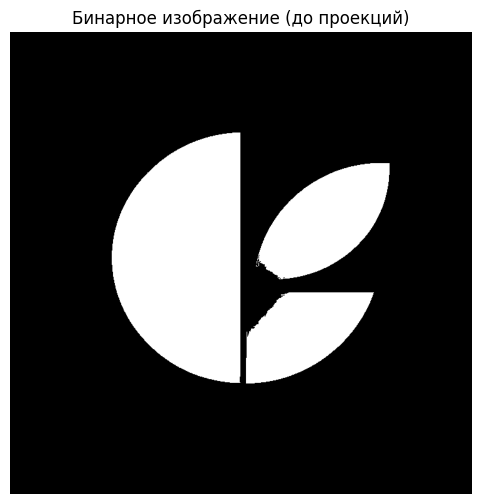

In [18]:
# Бинаризация методом Оцу
_, binary = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(6,6))
plt.imshow(binary, cmap='gray')
plt.title("Бинарное изображение (до проекций)")
plt.axis('off')
plt.show()

Теперь построим проекции и найдём границы объекта. Для построения горизонтальной и вертикальной проекций считаем сумму белых пикселей (255) по строкам и столбцам соответственно. Для поиска границ объекта находим строки и столбцы, где проекция > 0 (есть белые пиксели):
- Верхняя граница: первая строка с объектом (**y_min**)
- Нижняя граница: последняя строка с объектом (**y_max**)
- Левая граница: первый столбец с объектом (**x_min**)
- Правая граница: последний столбец с объектом (**x_max**)

Координаты (x_min, y_min) и (x_max, y_max) задают минимальный прямоугольник, содержащий все белые пиксели объекта.

 Границы объекта по вертикали: строки 161 – 562 (высота = 402)
 Границы объекта по горизонтали: столбцы 163 – 607 (ширина = 445)


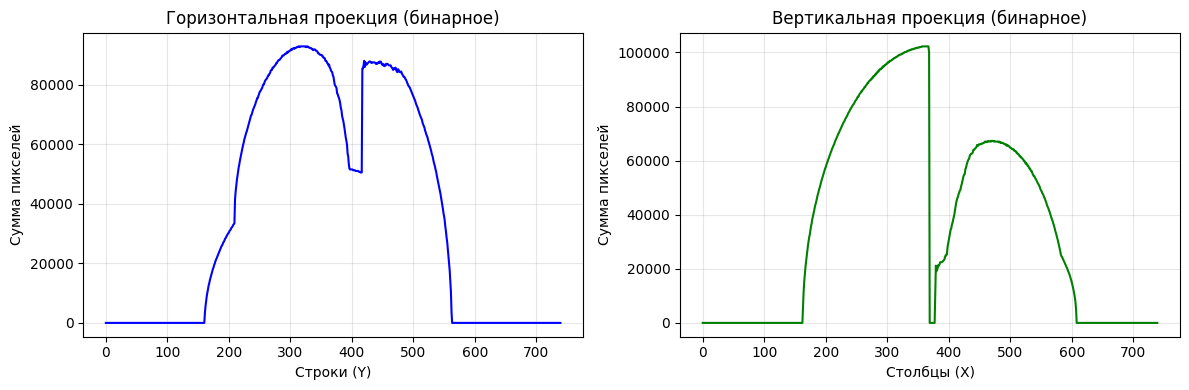

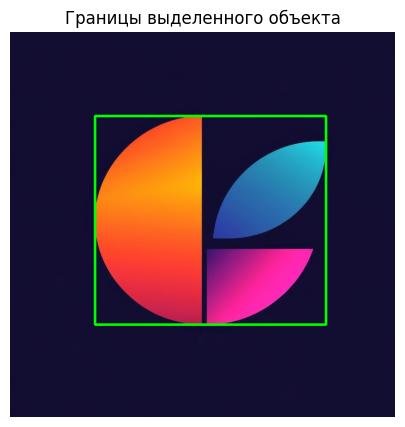

In [19]:
# Горизонтальная и вертикальная проекции бинарного изображения
h_proj_bin = np.sum(binary, axis=1)
v_proj_bin = np.sum(binary, axis=0)

# Поиск границ объектов (первые и последние ненулевые значения)
rows_with_obj = np.where(h_proj_bin > 0)[0]
cols_with_obj = np.where(v_proj_bin > 0)[0]

if len(rows_with_obj) > 0:
    y_min, y_max = rows_with_obj[0], rows_with_obj[-1]
    print(f' Границы объекта по вертикали: строки {y_min} – {y_max} (высота = {y_max - y_min + 1})')
else:
    print(' Объекты не найдены')

if len(cols_with_obj) > 0:
    x_min, x_max = cols_with_obj[0], cols_with_obj[-1]
    print(f' Границы объекта по горизонтали: столбцы {x_min} – {x_max} (ширина = {x_max - x_min + 1})')
else:
    print(' Объекты не найдены')

# Визуализация проекций
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h_proj_bin, color='blue')
axes[0].set_title('Горизонтальная проекция (бинарное)')
axes[0].set_xlabel('Строки (Y)')
axes[0].set_ylabel('Сумма пикселей')
axes[0].grid(True, alpha=0.3)

axes[1].plot(v_proj_bin, color='green')
axes[1].set_title('Вертикальная проекция (бинарное)')
axes[1].set_xlabel('Столбцы (X)')
axes[1].set_ylabel('Сумма пикселей')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Отображение бинарного изображения с рамкой границ
img_bound = original_image.copy()
if len(rows_with_obj) > 0 and len(cols_with_obj) > 0:
    cv2.rectangle(img_bound, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(img_bound, cv2.COLOR_BGR2RGB))
    plt.title('Границы выделенного объекта')
    plt.axis('off')
    plt.show()

**Ответы на контрольные вопросы:**
1. **Что такое гистограмма изображения и для чего она используется?** Гистограмма изображения — это график, показывающий распределение интенсивностей (яркости) пикселей. По оси X откладываются уровни яркости (от 0 до 255), а по оси Y — количество пикселей, имеющих данную яркость. Используется для оценки яркости, контраста, экспозиции изображения и выбора оптимального порога бинаризации.
2. **Чем отличается гистограмма цветного изображения от серого?** Для изображения в градациях серого строится одна гистограмма, которая показывает общее распределение яркости всех пикселей. Для цветного изображения строятся три отдельные гистограммы для каждого цветового канала, показывающие распределение интенсивности конкретного цвета.
3. **Что такое профиль изображения?** Профиль изображения — это одномерный массив (график), который показывает изменение средней интенсивности пикселей вдоль определенной оси (по строкам или по столбцам). Он позволяет выявлять наличие горизонтальных или вертикальных структур (например, полос или линий) на изображении.
4. **Как вычисляется горизонтальный и вертикальный профиль?** Горизонтальный профиль: вычисляется как среднее арифметическое значение яркости пикселей в каждой строке изображения. Вертикальный профиль: вычисляется как среднее арифметическое значение яркости пикселей в каждом столбце изображения.
5. **Что такое проекция изображения?** Проекция изображения — это одномерный массив, полученный путем суммирования интенсивностей пикселей вдоль определенной оси (по строкам или по столбцам).
6. **В чём разница между профилем и проекцией изображения?** Главная разница заключается в математической операции. Профиль использует операцию усреднения (mean). Он показывает среднюю яркость в строке/столбце и не зависит от размера объекта. Проекция использует операцию суммирования (sum). Она показывает общую сумму яркостей (или количество белых пикселей на бинарном изображении) и напрямую зависит от размера объекта в данной строке/столбце.
7. **Как гистограмма помогает в улучшении контраста изображения?** Гистограмма показывает, какой диапазон яркостей используется. Если график узкий и сосредоточен в центре, изображение имеет низкий контраст. Метод эквализации (выравнивания) гистограммы перераспределяет значения пикселей так, чтобы они равномерно заполнили весь доступный диапазон от 0 до 255. Это делает темные области темнее, а светлые — светлее, визуально увеличивая контраст.
8. **Как можно использовать горизонтальные и вертикальные проекции бинарного изображения?** На бинарном изображении (где объект = 255, фон = 0) проекции показывают количество белых пикселей в каждой строке или столбце. Это используется для: поиска точных координат границ объектов, выделения строк и столбцов текста при распознавании документов, определения наличия или отсутствия объекта в кадре.
9. **Как изменится гистограмма изображения после применения фильтра сглаживания?** Фильтры сглаживания устраняют резкие перепады яркости и шум. На гистограмме пики могут стать ниже, шире или объединиться.
10. **Что показывает пик на гистограмме изображения?** Пик на гистограмме показывает количество пикселей в изображении, которые имеют конкретное значение интенсивности (яркости или цвета). Чем выше пик, тем больше пикселей такого оттенка присутствует на картинке (например, высокий пик около 255 означает наличие большой светлой области или фона).